In [1]:
from bauer.models import MagnitudeComparisonModel, RiskModelProbabilityDistortion
import numpy as np
import pandas as pd

In [2]:
n = 10
paradigm = pd.DataFrame({'p1':np.random.rand(n), 'p2':np.random.rand(n), 'n1':np.ceil(np.random.rand(n)*100), 'n2':np.ceil(np.random.rand(n)*100)})

In [3]:
paradigm['choice'] = np.random.rand(n) < 0.5
# paradigm['subject'] = 1
# paradigm = paradigm.set_index('subject')

In [4]:
model = RiskModelProbabilityDistortion(paradigm)

In [5]:
parameters = {'magnitude_evidence_sd':0.005,
              'magnitude_prior_sd':0.01,
              'probability_evidence_sd':0.005,
              'probability_prior_sd':1.0,
              'probability_prior_mu':0.0}

In [ ]:
model.get

In [6]:
pred = model.predict(paradigm, parameters)

[10]


In [7]:
pred['ev1'], pred['ev2'] = pred['p1'] * pred['n1'], pred['p2'] * pred['n2']

pred['ev_diff'] = pred['ev2'] - pred['ev1']

<Axes: xlabel='ev_diff', ylabel='p_choice'>

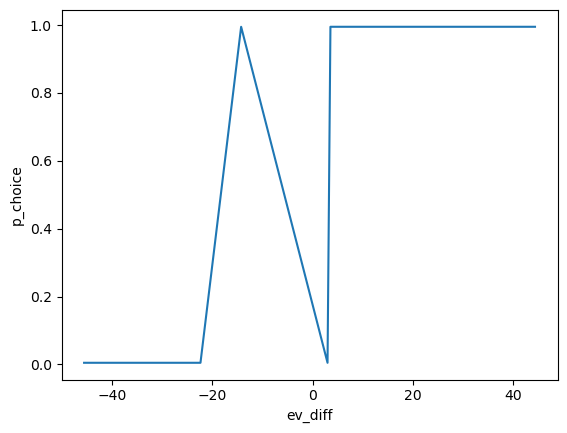

In [8]:
import seaborn as sns
sns.lineplot(x='ev_diff', y='p_choice', data=pred)

In [9]:
if not paradigm.index.name:
    paradigm.index.name = 'trial'

In [10]:
paradigm['ev1'], paradigm['ev2'] = paradigm['p1'] * paradigm['n1'], paradigm['p2'] * paradigm['n2']
paradigm['ev_diff'] = paradigm['ev2'] - paradigm['ev1']

In [11]:
simulated_data = model.simulate(paradigm, parameters, 50)

[10]


<Axes: xlabel='ev_diff', ylabel='simulated_choice'>

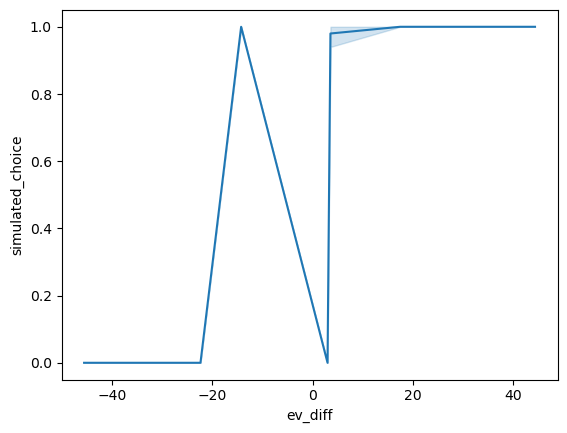

In [12]:
sns.lineplot(x='ev_diff', y='simulated_choice', data=simulated_data)

In [18]:
simulated_data['subject'] = 1
simulated_data.set_index('subject', append=True, inplace=True)

In [19]:
import pymc as pm
model.build_estimation_model(simulated_data, hierarchical=True)

with model.estimation_model:
    x = pm.find_MAP()

[500]


In [21]:
x

{'magnitude_evidence_sd_mu_untransformed': array(-0.8387226),
 'magnitude_evidence_sd_sd_log__': array(0.7781968),
 'magnitude_evidence_sd_offset': array([1.40519408]),
 'magnitude_prior_sd_mu_untransformed': array(1.080896),
 'magnitude_prior_sd_sd_log__': array(-9.1811233),
 'magnitude_prior_sd_offset': array([-0.00016777]),
 'probability_evidence_sd_mu_untransformed': array(-0.75933252),
 'probability_evidence_sd_sd_log__': array(-9.20154635),
 'probability_evidence_sd_offset': array([-3.03989517e-05]),
 'probability_prior_sd_mu_untransformed': array(-1.22481211),
 'probability_prior_sd_sd_log__': array(-9.17627393),
 'probability_prior_sd_offset': array([-0.00016393]),
 'probability_prior_mu_mu': array(0.45420185),
 'probability_prior_mu_sd_log__': array(-9.24721614),
 'probability_prior_mu_offset': array([0.00010481]),
 'magnitude_evidence_sd_sd': array(2.17754218),
 'magnitude_prior_sd_sd': array(0.00010296),
 'probability_evidence_sd_sd': array(0.00010088),
 'probability_prior_s

In [ ]:
model.p_grid

array([1.00000000e-06, 5.26324737e-02, 1.05263947e-01, 1.57895421e-01,
       2.10526895e-01, 2.63158368e-01, 3.15789842e-01, 3.68421316e-01,
       4.21052789e-01, 4.73684263e-01, 5.26315737e-01, 5.78947211e-01,
       6.31578684e-01, 6.84210158e-01, 7.36841632e-01, 7.89473105e-01,
       8.42104579e-01, 8.94736053e-01, 9.47367526e-01, 9.99999000e-01])

In [ ]:
import pytensor as pt

In [ ]:
pt.tensor.tile(5, 3).eval()

array([5, 5, 5], dtype=int8)

In [ ]:
paradigm = pd.DataFrame({'n1':np.arange(1, 11), 'n2':5., 'subject':np.repeat([5,6], 5)}).set_index('subject')

paradigm['choice'] = np.random.rand(10) > 0.5

In [ ]:
model = MagnitudeComparisonModel(data=paradigm)
# model.build_model()

In [ ]:
model.build_estimation_model(hierarchical=True)

In [ ]:
idata = model.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [ ]:
model.get_subjectwise_parameter_estimates(idata)

parameter           n1_evidence_sd  n2_evidence_sd
chain draw subject                                
0     0    5              0.243392        0.509575
           6              0.257884        0.467233
      1    5              0.101223        0.484074
           6              0.276090        0.391561
      2    5              0.651209        0.324221
...                            ...             ...
3     997  6              0.607279        0.491981
      998  5              0.354290        0.290382
           6              0.309735        0.340076
      999  5              0.545013        0.361734
           6              0.604731        0.535699

[8000 rows x 2 columns]

In [ ]:
parameters = {'n1_evidence_sd':1, 'n2_evidence_sd':1}

<Axes: xlabel='n1,n2'>

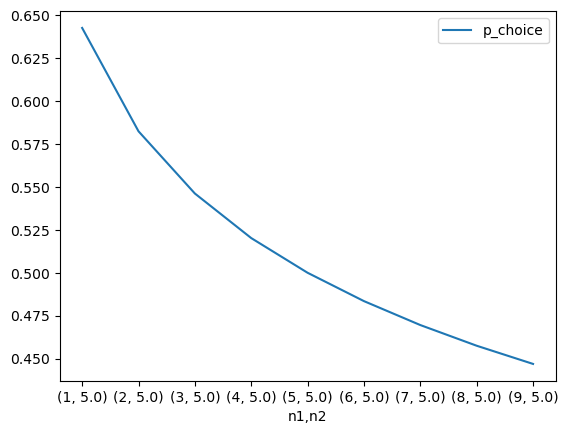

In [ ]:
pred1 = model.predict(paradigm, parameters)
pred1.plot()

<Axes: xlabel='n1,n2'>

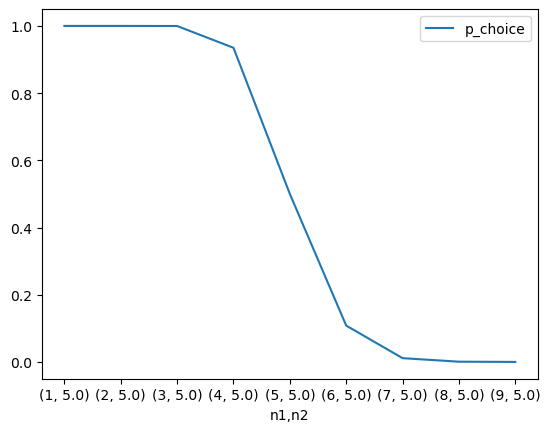

In [ ]:
parameters = {'n1_evidence_sd':.1, 'n2_evidence_sd':.1}
pred2 = model.predict(paradigm, parameters)
pred2.plot()
# pred1.plot()

In [ ]:
pm.draw(model.simulation_model['ll_bernoulli'])

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0])

In [ ]:
import matplotlib.pyplot as plt

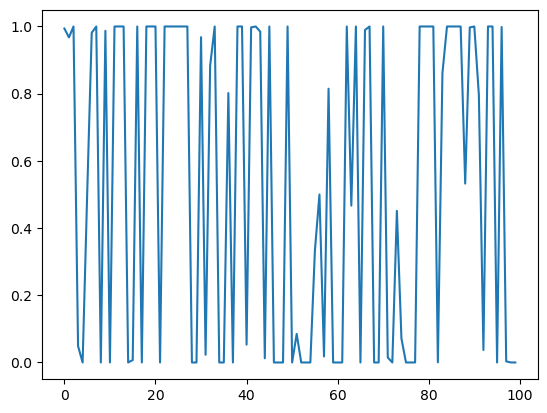

In [ ]:
plt.plot(model.simulation_model['p'].eval())

In [ ]:
model.sample()

AttributeError: 'MagnitudeComparisonModel' object has no attribute 'estimation_model'

In [ ]:
model.estimation_model['choice'].eval()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])